# Implicit Funciton toolboox for geophysics

If we can fit a point data to an Implicit Neural Network, we can operate directly on the Neural Network representation.

Ideas:
loss function z axis by grid levels
taylor expansion continuation

*Paper*
1. Use an INR for implicit gridding and calculate derivatives.
1. Compare against compressed sensing

*TODO*
1. Add val routine
1. Add Comet to run()
1. Consolidate notebooks and git branches
1. Tidy git repo (deprecate old code, clean notebook, validate batched vs non-batched one last time)

*Then:*
1. improve Z axis:
    1. Physics informed loss function?
    1. Predict a small grid and continue it using grid method...
    1. 

*Research questions*
1. Address micro levelling vs tie levelling! understand why microlevelling is required?
1. Block reduction of points
1. Compressed sensing comparison
1. Integrate multiple surveys over same area (careful of environment changes and IRGF!!!)

In [ ]:
%load_ext autoreload

%autoreload 2

import random
from pathlib import Path

import colorcet as cc
import comet_ml
import matplotlib.pyplot as plt
import numpy as np
import optuna
import tifffile
import torch
from tqdm.auto import tqdm
from torch.utils.data import random_split

from geoinr.datasets import NCDataset, CSVDataset, merge_z_slices, construct_xyz, device
import geoinr.batcheddatasets
from geoinr.models import RLoss, Siren
from geoinr.models import get_INR as wire
from geoinr.utils import query_inr, query_inr_batched, plt_inr, plt_cntr, plt_3d, plt_sample_locs

torch.manual_seed(seed := 0)
random.seed(seed)

In [ ]:
# file_path = Path(r"C:\Users\Public\scratch\Ch3\Ice_Cap.csv")
# dataset = geoinr.batcheddatasets.CSVDataset(
#     file_path, variable="MagF", usecols=("X", "Y", "Height_WGS84", "MagF")
# )
# dataset = dataset.subsample_wesnbt((-0.5, 0.6, -0.5, 0.5, -1, 1))
# train_dataset, val_dataset = random_split(dataset, [0.3, 0.7])
# print(f"{len(train_dataset)=}, {len(val_dataset)=}")

In [ ]:
netcdf_path = Path(r"/home/luke/PhD/ch3/implicitgeo/data/P864-line-magnetic-AWAGS_MAG_2010.nc")
gtt_path = Path(r"/home/luke/PhD/ch3/implicitgeo/data/P864-grid-tmi.tif")

dataset = geoinr.batcheddatasets.NCDataset(netcdf_path, variable="mag_microLevelled")

# netcdf_path = Path(r"C:\Users\Public\scratch\Ch3\P1260\P1260-line-magnetic-AWAGS_MAG_2010.nc")
# dataset = geoinr.batcheddatasets.NCDataset(netcdf_path, variable="mag_microlevelled")
# dataset = dataset.subsample_wesnbt((
#               dataset.normalise(250000, "x"), dataset.normalise(270000, "x"),
#               dataset.normalise(6.755e6, "y"), dataset.normalise(6.765e6, "y"),
#              -1, 1,))

train_dataset, val_dataset = random_split(dataset, [0.85, 0.15])
print(f"{len(train_dataset)=}, {len(val_dataset)=}")
print(f"Dropped {dataset.invalid_points} invalid points")

In [ ]:
dataset.plot_variables(["altitude"], figsize=(10, 5), dpi=160)

In [ ]:
plt_sample_locs(dataset, "b")

In [ ]:
print(dataset.ncd.variables.keys())
# dataset.plot_variables(
#     ["mag_tieLevelled", "mag_microlevelled", "mag_awagsLevelled"], s=0.01, dpi=300
# )
# "microlevelling removes low amplitude flight line noise after tie line levelling."
# dataset.plot_variables(["altitude"], s=0.01, dpi=100)

In [ ]:
def run_experiment(f, dataloaders: dict, opt: dict):
    def train_epoch(dataloader, step):
        f.train()
        for iteration, batch in enumerate(dataloader):
            exp.set_step(step)
            exp.log_parameter("lr", sched.get_last_lr())

            # Send the data to the model and predict
            train_xyz = batch[0].to(device, non_blocking=True)
            train_u = batch[1].to(device, non_blocking=True)

            with torch.amp.autocast(opt["device"], enabled=opt["use_amp"]):
                pred_u, gt_xyz = f(train_xyz)
                # pred_u = pred_u.to(dtype=torch.bfloat16)
                gt_xyz = None  # Not needed here TODO method to prevent generation

                # Calculate Loss
                loss_mse = cri_mse(pred_u, train_u)
                if opt["weight_rloss"] > 0:
                    xbar = torch.rand_like(train_xyz[:, : opt["n_samples"], :])
                    loss_r = cri_r(f, xbar, opt["n_samples"])
                    loss_total = loss_mse + opt["weight_rloss"] * loss_r
                else:
                    loss_total = loss_mse

            optim.zero_grad(set_to_none=True)
            loss_total.backward()
            optim.step()
            sched.step()

            # Log metrics
            exp.log_metric("Train Loss Total", loss_total.item())
            exp.log_metric("Train Loss MSE", loss_mse.item())
            if opt["weight_rloss"] > 0:
                exp.log_metric("Train Loss Regularisation", loss_r.item())

            step += 1

        return step

    def val_epoch(dataloader):
        f.eval()
        avg_metric = []
        for viter, d in enumerate(dataloader):
            val_xyz = d[0].to(device, non_blocking=True)
            val_u = d[1].to(device, non_blocking=True)

            pred_u, gt_xyz = f(val_xyz)
            gt_xyz = None

            avg_metric.append(cri_mse(pred_u, val_u).item())

        avg_metric = np.array(avg_metric).mean()
        exp.log_metric("Val Loss MSE", avg_metric)

        return avg_metric

    def log_figure():
        u = query_inr(f, (200, 200, 1))

        fig = plt_inr(
            u,
            altitude=dataset.unnormalise(0, "z"),
            extent=dataset.extent,
            ax_args=dict(cmap=cc.cm.CET_L1),
            _vmin=min(dataset.var_ranges["u"]),
            _vmax=max(dataset.var_ranges["u"]),
            cropping=(50, 400),
            figsize=(8, 4),
            dpi=80,
        )
        exp.log_figure("INR: Selected height", figure=fig, step=step)
        plt.close()

    def init_comet():
        if "sinusoidal" in opt["nonlinearity"]:
            comet_tags = ["SIREN"]
        elif "wire" in opt["nonlinearity"]:
            comet_tags = ["WIRE"]

        exp = comet_ml.Experiment(disabled=False)
        exp.add_tags(comet_tags)
        exp.log_code("geoinr/models.py")
        exp.log_code("geoinr/datasets.py")
        exp.log_parameter("dataset", dataset.file_path.name)
        exp.log_parameters(opt)

        return exp

    # Run
    exp = init_comet()
    trial = None

    optim = torch.optim.Adam(lr=opt["initial_lr"], params=f.parameters())
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optim,
        steps_per_epoch=len(dataloaders["train"]),
        epochs=opt["total_epochs"],
        max_lr=opt["initial_lr"],
    )
    cri_mse = torch.nn.MSELoss()
    cri_r = RLoss(Sigma=opt["rloss_Sigma"], device=opt["device"])

    step = 0
    for epoch in tqdm(range(opt["total_epochs"]), unit="epoch", desc="Training"):
        exp.set_epoch(epoch)

        step = train_epoch(dataloaders["train"], step)

        if (epoch + 1) % 10 == 0:
            with torch.no_grad():
                val_metric = val_epoch(dataloaders["val"])
        if (epoch + 1) % 100 == 0:
            with torch.no_grad():
                log_figure()

            if trial is not None:
                trial.report(val_metric, step)
                if trial.should_prune():
                    exp.add_tag("Pruned")
                    exp.end()
                    raise optuna.TrialPruned()

    exp.end()
    print(f"Total steps: {step}")
    return f

In [13]:
# rloss_Sigma = 1e-3 * abs(
#     (1 / (max(dataset.var_ranges["x"]) - min(dataset.var_ranges["x"])))
# )

train_opts = dict(
    total_epochs=1_000,  # 00,
    batch_size=100_000,  # 2_048_000,  # 1M for 12 GB
    initial_lr=5e-5,
    nonlinearity="sinusoidal",
    hidden_layers=4,
    weight_rloss=0.1,  # 1e-4,
    rloss_Sigma=1e-6,  # Scaled per x width
    n_samples=int(0.1 * dataset.u.shape[0]),  # 10% samples for RLoss
    wire_omega_0=10,
    wire_sigma=10,
    device="cuda",
    use_amp=False,
    gt_tiff=tifffile.imread(gtt_path)
)

train_dataloader = geoinr.batcheddatasets.BatchingDataloader(
    train_dataset,
    batch_size=train_opts["batch_size"],
    pin_memory=True,
)

val_dataloader = geoinr.batcheddatasets.BatchingDataloader(
    val_dataset,
    batch_size=train_opts["batch_size"],
    pin_memory=True,
)

if train_opts["nonlinearity"] in ["sinusoidal", "siren"]:
    comet_tags = ["SIREN"]
    model = Siren(
        in_features=3,
        out_features=1,
        hidden_features=256,
        hidden_layers=train_opts["hidden_layers"],
        outermost_linear=True,
    )

elif "wire" in train_opts["nonlinearity"]:
    comet_tags = ["WIRE"]
    f = wire(
        nonlin=train_opts["nonlinearity"],  # "wire2d" | "wire3d"
        in_features=3,
        out_features=1,
        hidden_features=256,
        hidden_layers=train_opts["hidden_layers"],
        first_omega_0=train_opts["wire_omega_0"],  # first Frequency of sinusoid
        hidden_omega_0=train_opts["wire_omega_0"],  # hidden Frequency of sinusoid
        scale=train_opts["wire_sigma"],  # Sigma of Guassian
        pos_encode=False,
        sidelength=None,  # only for pos_encode
    )

f = model.to(device, non_blocking=True)

inr = run_experiment(
    f,
    {"train": train_dataloader, "val": val_dataloader},
    train_opts,
)

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/lukesmithgeo/geoinr/a15d5eccc09d4a12a87df4f93be04120



Training:   0%|          | 0/1000 [00:00<?, ?epoch/s]

COMET INFO: Uploading 1 metrics, params and output messages
COMET INFO: Please wait for assets to finish uploading (timeout is 10800 seconds)
COMET INFO: All assets have been sent, waiting for delivery confirmation


Total steps: 1000


In [14]:
import functools

if tune := 0:
    def objective(trial: optuna.Trial, dataset, device):
        tune_opts = {
            **train_opts,
            **dict(
                initial_lr=trial.suggest_float("initial_lr", 4e-5, 4e-5, log=True),
                hidden_layers=trial.suggest_int("hidden_layers", 3, 3),
                omega_0=trial.suggest_float("omega_0", 10, 30, step=10),
                sigma=trial.suggest_float("sigma", 10, 30, step=10),
            ),
        }

    objective = functools.partial(objective, dataset=dataset, device=device)

    study = optuna.create_study(
        study_name="geoinr_test",
        direction="minimize",
        # pruner=optuna.pruners.ThresholdPruner(upper=0.1, n_warmup_steps=100),
        storage="sqlite:///inr.db",
        load_if_exists=True,
    )
    study.optimize(objective, n_trials=1)

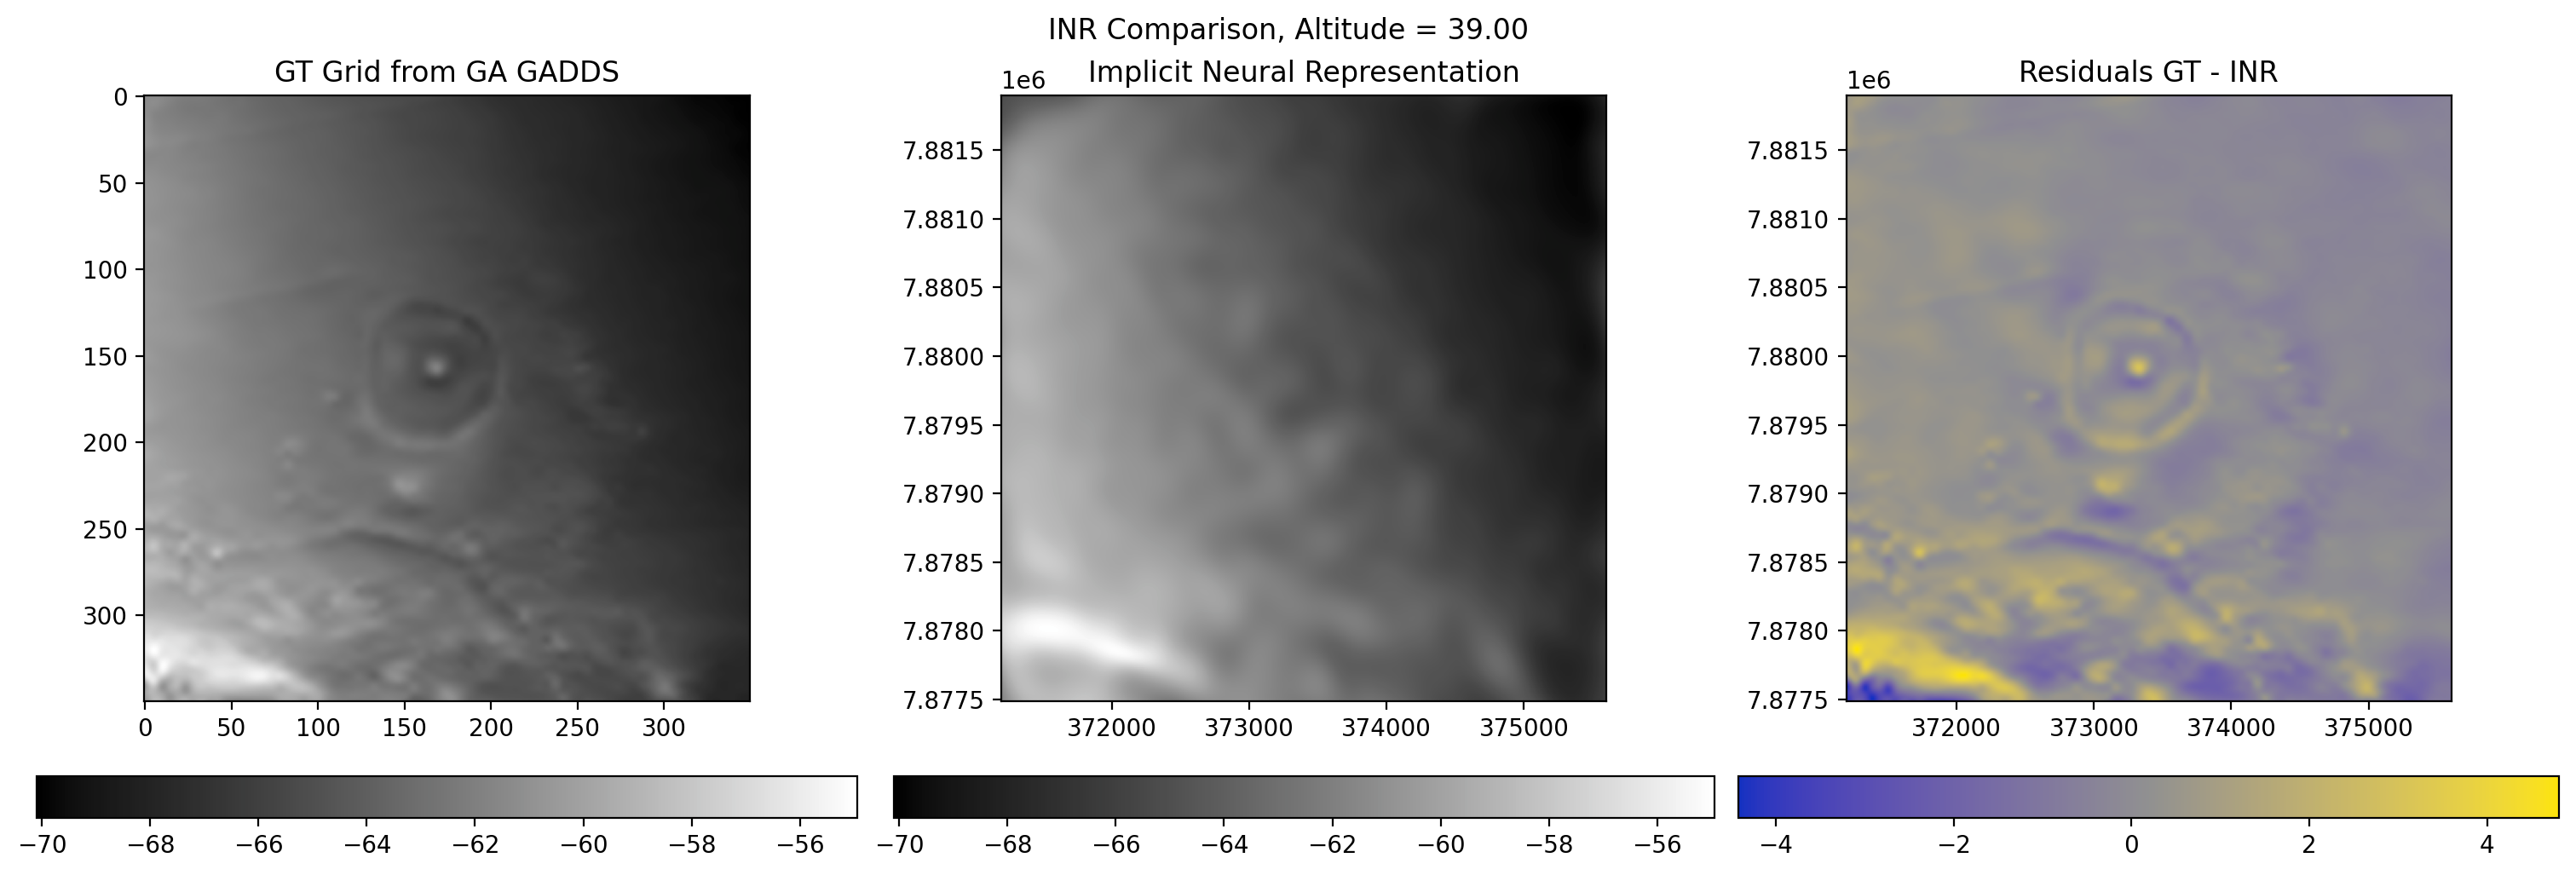

In [15]:
# Set up parameters for querying
gtt = tifffile.imread(gtt_path)
normalise_fn = dataset.normalise
unnormalise_fn = dataset.unnormalise

shape = (gtt.shape[1], gtt.shape[0], 1)
altitude = 39  # dataset.ncd.variables["altitude"][:].mean()
z_mod = normalise_fn(altitude, "z")
altitude = unnormalise_fn(z_mod, "z")

extent = [
    unnormalise_fn(dataset.extent[0], "x"),
    unnormalise_fn(dataset.extent[1], "x"),
    unnormalise_fn(dataset.extent[2], "y"),
    unnormalise_fn(dataset.extent[3], "y"),
]

ax_args = dict(cmap=cc.cm.CET_L1)

u = query_inr_batched(
    inr,
    shape=shape,
    chunksize=1_024_000,
    z_mod=z_mod,
    # x_vec=torch.linspace(dataset.extent[0], dataset.extent[1], steps=shape[0]),
    # y_vec=torch.linspace(dataset.extent[2], dataset.extent[3], steps=shape[1]),
    # z_vec = normalise_fn(torch.linspace(40, 60, steps=shape[2]), "z")
)
u = unnormalise_fn(u, "u")

fig = plt_inr(
    u.squeeze(),
    altitude,
    extent=extent,
    ax_args=ax_args,
    gt_grid=gtt,
    figsize=(15, 5),
    cropping=(50, 400),
    dpi=200,
)

ValueError: operands could not be broadcast together with shapes (350,350) (250,0) 

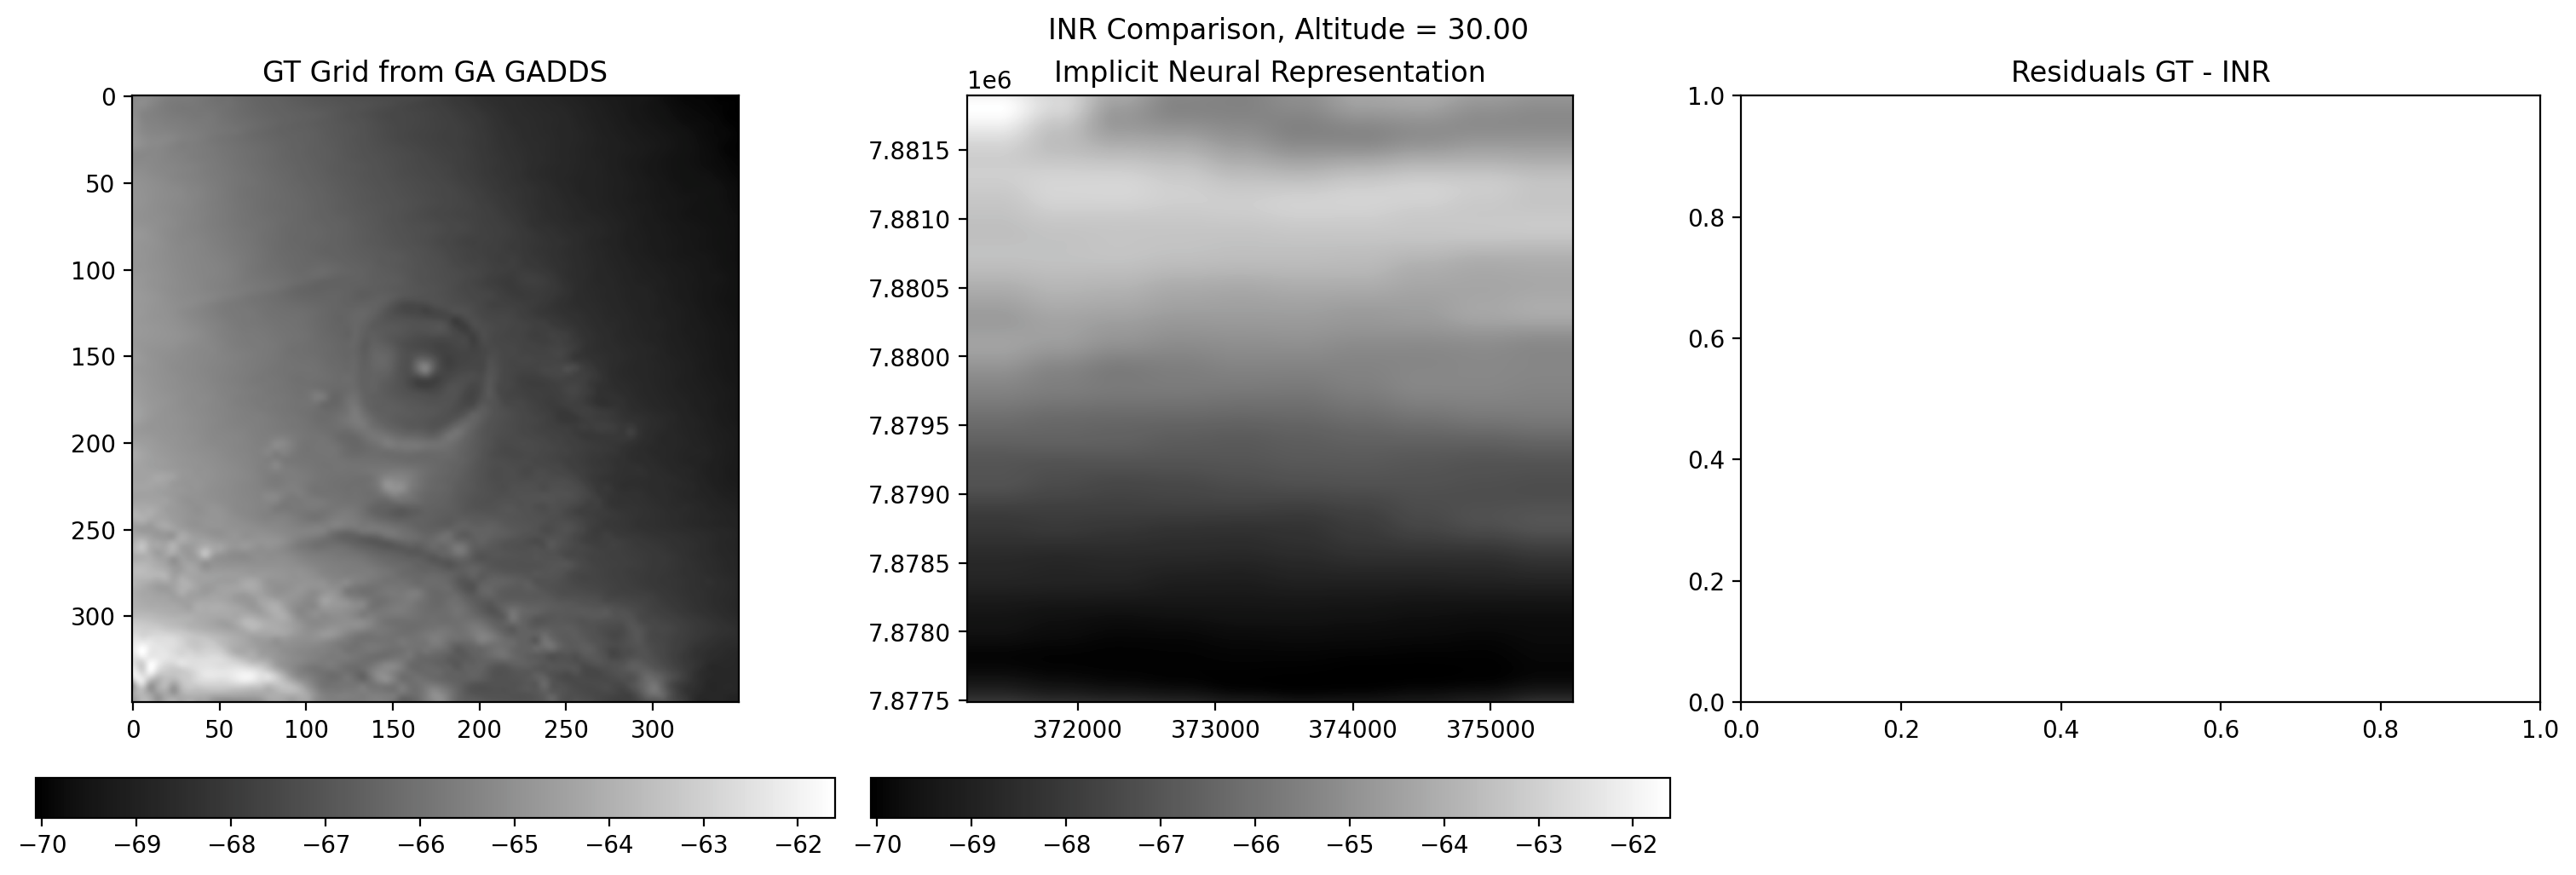

In [11]:
# Batched 3D volume query
shape = (456, 455, 10)  # shape(0,1) needs to match GT shape for comparisons
z_vec = normalise_fn(torch.linspace(30, 45, steps=shape[2]), "z")

## TODO: query_inr_batched returns zxyu for easy iteration. Refactor!
u = query_inr_batched(f, shape=(300,300,10), chunksize=256_000, z_vec=z_vec)
u = unnormalise_fn(u, "u")

for i, u in enumerate(u):
    altitude = unnormalise_fn(z_vec[i], "z")
    fig = plt_inr(
        u,
        altitude,
        extent=extent,
        ax_args=ax_args,
        gt_grid=gtt,
        figsize=(15, 5),
        cropping=(50, 400),
        dpi=200,
    )
    plt.show()

In [12]:
plt_3d(
    u, ori="z", levels=20, step=21, elev=30, azim=100, linear_width=30, alpha=0.1
)

IndexError: tuple index out of range

In [ ]:
# Noddyverse Synthetic Comparison
plt_3d(
    u=merge_z_slices(Path("/home/luke/PhD/ch3/implicitgeo/data"), idx=0),
    ori="z",
    step=20,
    elev=50,
    azim=123,
    linear_width=1000,
    cmap=cc.cm.CET_L20,
    alpha=0.5,
)

Explicit function: $$u(x,y,z) = \sin(x+y+z) + \cos(x-y-z)$$

Explicit x, y, z partial derivatives:
$$\frac{\partial{u(x,y,z)}}{\partial{x}} = \cos(x+y+z) - \sin(x-y-z)$$ 
$$\frac{\partial{u(x,y,z)}}{\partial{y}} = \cos(x+y+z) + \sin(x-y-z)$$
$$\frac{\partial{u(x,y,z)}}{\partial{z}} = \cos(x+y+z) + \sin(x-y-z)$$

In [ ]:
## Custom Function sample:
# TODO make a custom geophysical test grid with just a box.
def cust_f(d=200, a=1, l=1):
    x, y, z = np.meshgrid(
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        indexing="xy",
    )
    u = a * (np.sin(x + y + z) + np.cos(x - y - z))
    return (x, y, z, u)


def cust_df(d=200, a=1, l=1):
    x, y, z = np.meshgrid(
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        indexing="xy",
    )
    dudx = a * (np.cos(x + y + z) - np.sin(x - y - z))
    dudy = a * (np.sin(x - y - z) + np.cos(x + y + z))
    dudz = a * (np.sin(x - y - z) + np.cos(x + y + z))

    return (dudx, dudy, dudz)

In [ ]:
a = 1
l = 4
x, y, z, u = cust_f(d=200, a=a, l=l)
dudx, dudy, dudz = cust_df(d=50, a=a, l=l)
plt.imshow(u[25])
# plt_3d(u, ori="z", step=50, elev=33, azim=120, linear_width=1, alpha=1)

In [ ]:
opts = dict(ori="x", step=10, elev=45, azim=135, linear_width=1, cmap=cc.cm.CET_L1)

fig = plt.figure(figsize=(30, 10), layout="constrained")
ax = fig.add_subplot(131, projection="3d")
plt_3d(dudx, **opts, ax=ax, fig=fig)
ax = fig.add_subplot(132, projection="3d")
plt_3d(dudy, **opts, ax=ax, fig=fig)
ax = fig.add_subplot(133, projection="3d")
plt_3d(dudz, **opts, ax=ax, fig=fig)
# plt_3d(dudx, **opts, ax=fig.add_subplot(234, projection="3d"))
# plt_3d(dudy, **opts, ax=fig.add_subplot(235, projection="3d"))
# plt_3d(dudz, **opts, ax=fig.add_subplot(236, projection="3d"))

So we've established that an Implicit function such as SIREN can learn a grid extent quite well.  
Now we want to calculate the gradients (Jacobian) using the network.  
We do this as a calculation of the gradients between the model inputs (x,y) and the model output (u) which is the TMI at that x,y point.

There are several ways to calculate the Jacobian:  
1. `torch.autograd.grad`
1. `torch.autograd.functional.jacobian(vectorize=True)`
1. `functorch.jacrev`

https://github.com/pytorch/pytorch/issues/23475#issuecomment-946927242

We want the Jacobian: $$J(x,y) = [\frac{\partial{u(x,y)}}{\partial{x}}, \frac{\partial{u(x,y)}}{\partial{y}}]$$

Where $$ u = f(x,y)\,,\, f:R^2 \to R^1$$
This is the special case where _the Jacobian matrix reduces to the row vector $${\displaystyle \nabla ^{\mathrm {T} }f}$$ this row vector of all first-order partial derivatives of f is the transpose of the gradient of f $${\displaystyle \mathbf {J} _{f}=\nabla ^{T}f}. $$_



In [ ]:
def gradient(u, xyz, grad_outputs=None):
    if grad_outputs is None:
        grad_outputs = torch.ones_like(u)
    grad = torch.autograd.grad(u, [xyz], grad_outputs=grad_outputs, create_graph=True)[
        0
    ]
    return grad


def divergence(u, xyz):
    div = 0.0
    for i in range(u.shape[-1]):
        div += torch.autograd.grad(
            u[..., i], xyz, torch.ones_like(u[..., i]), create_graph=True
        )[0][..., i : i + 1]
    return div


def laplace(u, xyz):
    return divergence(gradient(u, xyz), xyz)


def s_jacobian(u, xyz):
    """jacobian of u wrt x"""
    meta_batch_size, num_observations = u.shape[:2]
    jac = torch.zeros(meta_batch_size, num_observations, u.shape[-1], xyz.shape[-1]).to(
        u.device
    )  # (meta_batch_size*num_points, 2, 2)
    for i in range(u.shape[-1]):
        # calculate dydx over batches for each feature value of y
        u_flat = u[..., i].view(-1, 1)
        jac[:, :, i, :] = torch.autograd.grad(
            u_flat, xyz, torch.ones_like(u_flat), create_graph=True
        )[0]

    status = 0
    if torch.any(torch.isnan(jac)):
        status = -1

    return jac, status

In [ ]:
## Simple method for "Gradient", torch.autograd.grad
## The gradient is a special case of the Jacbian, when the function is scalar
## https://math.stackexchange.com/questions/1519367/difference-between-gradient-and-jacobian


shape = (200, 200, 1)
query_xyz = construct_xyz((200, 200, 1), z_mod=-0.4)
query_xyz.requires_grad_(True)
query_xyz = query_xyz.to(device)

pred_u, query_xyz = inr(query_xyz)
pred_u = dataset.unnormalise(pred_u, var="u")

grad = torch.autograd.grad(
    outputs=pred_u,
    inputs=[query_xyz],
    grad_outputs=torch.ones_like(pred_u),
    create_graph=True,
    retain_graph=True,
    allow_unused=True,
)
# grad = [grad[0]]
# print(f"{grad[0].shape = }")

In [ ]:
# First Derivative?
dudx, dudy, dudz = grad[0].detach().cpu().squeeze().permute(1, 0)

ax_args = dict(cmap=cc.cm.CET_L1, extent=extent)

plt.figure(constrained_layout=True, figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title("dudx")
plt.imshow(dudx.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")
plt.subplot(1, 3, 2)
plt.title("dudy")
plt.imshow(dudy.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")
plt.subplot(1, 3, 3)
plt.title("dudz")
plt.imshow(dudz.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")

In [ ]:
# Second Derivative?
grad2 = torch.autograd.grad(
    outputs=[grad[0]],
    inputs=[query_xyz],
    grad_outputs=torch.ones_like(grad[0]),
    create_graph=True,
    retain_graph=True,
    allow_unused=True,
)
dxx, dyy, dzz = grad2[0].detach().cpu().squeeze().permute(1, 0)


plt.figure(constrained_layout=True, figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title("dxx")
plt.imshow(dxx.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")
plt.subplot(1, 3, 2)
plt.title("dyy")
plt.imshow(dyy.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")
plt.subplot(1, 3, 3)
plt.title("dzz")
plt.imshow(dzz.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")

## TODO

In [ ]:
xmin = dudx.min()
xmax = dudx.max()
ymin = dudy.min()
ymax = dudy.max()

plt.figure(constrained_layout=True, figsize=(10, 10))
plt.subplot(221)
plt.title("Analytical dudx")
plt_cntr(dx)
plt.subplot(222)
plt.title("Implicit dudx")
plt.imshow(dudx, origin="lower", cmap=cc.cm.CET_L1, vmin=xmin, vmax=xmax)
plt.colorbar()
plt.subplot(223)
plt.title("Analytical dudy")
plt_cntr(dudy)
plt.subplot(224)
plt.title("Implicit dudy")
plt.imshow(dy, origin="lower", cmap=cc.cm.CET_L1, vmin=ymin, vmax=ymax)
plt.colorbar()

In [ ]:
def gradients(pred_u, xy_coord):
    """Compute the xx and yy gradients of the Implicit Function
    When trained, inputs of (x,y) coords to a Siren model (F) return u.
    Generally, this is u = F(x,y)
    """
    return (
        torch.autograd.grad(
            outputs=pred_u,
            inputs=[xy_coord],
            grad_outputs=torch.ones_like(pred_u),
            create_graph=True,
            retain_graph=True,
            allow_unused=True,
        )[0]
        .detach()
        .reshape(dset.s, dset.s, 2)
        .permute(2, 0, 1)
        .cpu()
        # .numpy()
    )


# Below references are per Blakely, R. J. 1996
# _Potential Theory in Gravity and Magnetic Applications_
# Cambridge University Press


def horizontal_gradient(dudy, dudx):
    """Horizontal Gradient, eqn 12.49"""
    # return torch.sqrt(dudx ** 2 + dudy ** 2)
    return torch.dstack((dudy, dudx)).norm(dim=-1, p="fro")


def upward_continuation():
    """Upward Continuation, eqn 12.4
    It would be interesting to include u in the coords, and predict this
    """
    # (dz / 2 * pi) * double integral (output_xyz0) / ((x-x')^2 + (y-y')^2 + (dz**2))**(3/2) dxdy

    return NotImplementedError


def downward_continuation(du):
    """Downward Continuation, eqn 12.5
    args:
        - du: vertical distance to downward continue



    """

    return NotImplementedError


def vertical_derivative(order=1):
    """Vertical Derivative, eqn 12.17
    Args:
        order (int): Order of derivative, e.g. 2 for 2VD

    """
    return NotImplementedError

In [ ]:
pred_u, xy_coord = img_siren(model_input)
dudy, dudx = gradients(pred_u, model_input)
horiz_g = horizontal_gradient(dudy, dudx)

In [ ]:
plt.imshow(horiz_g, cmap=cc.cm.CET_L1, origin="lower")
plt.title("Horizontal Gradient")

In [ ]:
crop = dset.original_shape
# w,e,s,n = (0, crop[-2], 0, crop[-1])
w, e, s, n = zoom

In [ ]:
import matplotlib.colors as colors

fig, axs = plt.subplots(3, 2, layout="constrained", figsize=(10, 12))
plt.suptitle(f"Horizontal Derivatives - {sample.stem}")
plt_opts = dict(origin="upper", cmap=cc.cm.CET_L1)
[[axg, axp], [axx, axy], [axh, axoff]] = axs

axg.set_title(r"Original TMI Grid")
caxi = axg.imshow(
    dset.original_grid.squeeze()[s:n, w:e], cmap=cc.cm.CET_L1, origin="lower"
)
plt.colorbar(mappable=caxi, ax=axg, label=r"nT", location="bottom")

axp.set_title(r"Learnt TMI Grid")
caxp = axp.imshow(
    pred_u.detach().cpu().view(dset.s, dset.s).squeeze()[s:n, w:e], cmap=cc.cm.CET_L1
)
plt.colorbar(mappable=caxp, ax=axp, label=r"nT", location="bottom")

axh.set_title(r"Horizontal gradient")
caxh = axh.imshow(horiz_g[s:n, w:e], cmap=cc.cm.CET_L1, vmin=0, vmax=10)
plt.colorbar(mappable=caxh, ax=axh, label=r"nT/cell", location="bottom")

axx.set_title(r"$\delta$u$\delta$x")
caxx = axx.imshow(dudx[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxx, ax=axx, label=r"nT/cell", location="bottom")

axy.set_title(r"$\delta$u$\delta$y")
caxy = axy.imshow(dudy[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxy, ax=axy, label=r"nT/cell", location="bottom")

# norm = colors.LogNorm(vmin=0.1, vmax=60)
axoff.axis("off")

for ax in axs.ravel():
    ax.set_xlabel("x")
    ax.set_ylabel("y")

In [ ]:
# ## SPARE BITS###


# # from functorch import vmap, vjp, jacrev

# # vmap(jacrev(img_siren))(model_input)
# ###

# j = (dudx, dudy) = torch.autograd.functional.jacobian(lambda t: img_siren(t), model_input)#, vectorize=True)
# ###

# ## Sitzmann et al. method (non vectorised)
# meta_batch_size = pred_u.shape[0]  # only 1 tile
# num_observations = pred_u.shape[1]  # Num XYZ points,
# out_vecs = pred_u.shape[-1]  # num output channels, 1
# in_ch = xy_coord.shape[-1]  # num input channels, 2

# jac = torch.zeros(meta_batch_size, num_observations, out_vecs, in_ch).to(
#     pred_u.device
# )  # (meta_batch_size*num_points, 2, 2)
# for vec in range(out_vecs):
#     # calculate dydx over batches for each feature value of y
#     y_flat = pred_u[..., vec].view(-1, 1)
#     jac[:, :, vec, :] = torch.autograd.grad(
#         y_flat, xy_coord, torch.ones_like(y_flat), create_graph=True
#     )[0]

# ###

# jac2 = jac.squeeze().reshape(200,200,2).permute(2,0,1)[1]
# plt.imshow(jac2.detach().cpu().numpy())
# plt.colorbar()
# ###


# from functorch import vmap, vjp, jacrev

# def f(x):
#     return img_siren(x)

# j = jacrev(f)(model_input.squeeze())

# print(model_input.squeeze().shape)
# print(f"{j[0].shape=}")
# print(f"{j[1].shape=}")

# ###

# ## As of pytorch 1.13, we can now use functorch operations
# ## https://pytorch.org/functorch/stable/notebooks/jacobians_hessians.html

# # from functorch import vmap, vjp, jacfwd, jacrev
# # torch.manual_seed(0)

# # img_siren

# # m = model_input.clone().requires_grad_()

# # cotangents = torch.eye(m.shape[1])
# # _, vjp_fn = vjp((img_siren), m)
# # vmap(vjp_fn)(cotangents)

# # # ft_jacobian = jacrev(img_siren, argnums=(0,))(m)

# # # ft_jacobian = vmap(jacrev(img_siren, argnums = 0), in_dims=(None, 0, None))
# # # btach_jac = ft_jacobian( )

# # model_output, coords = img_siren(model_input)
# # print(f"{model_input.shape=}")
# # print(f"{img_siren(model_input)[0].shape=}")
# # print(f"{img_siren(model_input)[1].shape=}")

# # j = torch.autograd.functional.jacobian(lambda x: img_siren(x)[0], model_input, vectorize=True)
# # j2 = torch.diagonal(j, offset=0, dim1=0, dim2=2)
# # j3 = j2.permute(2,0,1)

# # j2.shape
# # j.squeeze()[1].reshape(s, s, 2).shape